# ML Head and Shoulders Pattern Detection with CNN

This notebook trains a Convolutional Neural Network to detect the
head-and-shoulders technical trading pattern in Forex price data.

The model is saved to the Object Store for use by `main.py`.

Source: HandsOnAITradingBook, Section 06, Example 17

> **[REFERENCE QC Cloud]**
> Ce notebook utilise QuantBook et necessite l'environnement QuantConnect Cloud.
> Pour executer : https://www.quantconnect.com/research


In [1]:
from AlgorithmImports import *
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Dense, Flatten
from tensorflow.keras import Model
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.model_selection import train_test_split
import json

2026-05-12 18:30:18.592059: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 18:30:18.752996: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778610618.821026      37 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778610618.840568      37 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778610618.977186      37 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

/opt/miniconda3/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Step 1: Load USDCAD Price Data

Load historical daily USDCAD prices for pattern analysis.

In [2]:
qb = QuantBook()
symbol = qb.add_forex("USDCAD", Resolution.DAILY).symbol

start_date = datetime(2015, 1, 1)
end_date = datetime(2024, 1, 1)

history = qb.history(
    symbol, start_date, end_date, Resolution.DAILY
).close
prices = history.droplevel(0)
print(f"Loaded {len(prices)} daily prices")
prices.head()

AttributeError: 'DataFrame' object has no attribute 'close'

## Step 2: Generate Synthetic Training Data

Create synthetic head-and-shoulders patterns and random price
movements for training the CNN classifier.

In [3]:
def generate_head_and_shoulders(n_points=25, noise_std=0.01):
    """Generate a synthetic head-and-shoulders price pattern."""
    x = np.linspace(0, 1, n_points)
    # Left shoulder, head, right shoulder pattern
    pattern = (
        0.3 * np.exp(-((x - 0.2) ** 2) / 0.01)
        + 0.5 * np.exp(-((x - 0.5) ** 2) / 0.015)
        + 0.3 * np.exp(-((x - 0.8) ** 2) / 0.01)
    )
    noise = np.random.normal(0, noise_std, n_points)
    return pattern + noise


def generate_random_walk(n_points=25, noise_std=0.02):
    """Generate a random walk price series (non-pattern)."""
    returns = np.random.normal(0, noise_std, n_points)
    return np.cumsum(returns)


n_samples = 2000
n_points = 25

X = []
y = []

for _ in range(n_samples // 2):
    hs = generate_head_and_shoulders(n_points)
    hs_standardized = (hs - hs.mean()) / hs.std()
    X.append(hs_standardized.reshape(n_points, 1))
    y.append(1)  # Pattern present

    rw = generate_random_walk(n_points)
    rw_standardized = (rw - rw.mean()) / rw.std()
    X.append(rw_standardized.reshape(n_points, 1))
    y.append(0)  # No pattern

X = np.array(X)
y = np.array(y)

print(f"Training data: {X.shape[0]} samples, {X.shape[1]} timesteps")
print(f"Positive samples (HS pattern): {y.sum()}")
print(f"Negative samples (random): {(1 - y).sum()}")

Training data: 2000 samples, 25 timesteps
Positive samples (HS pattern): 1000
Negative samples (random): 1000


## Step 3: Build and Train CNN Model

Create a simple 1D Convolutional Neural Network for binary
classification of head-and-shoulders patterns.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

inputs = Input(shape=(n_points, 1))
x = Conv1D(16, 3, activation='relu')(inputs)
x = Conv1D(32, 3, activation='relu')(x)
x = Flatten()(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer='adam',
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=30, batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy: {accuracy:.4f}")
print(f"Test loss: {loss:.4f}")

Epoch 1/30


2026-05-12 18:30:23.099991: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


 1/50 ━━━━━━━━━━━━━━━━━━━━ 40s 825ms/step - accuracy: 0.5312 - loss: 0.6885

19/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8337 - loss: 0.5251   

38/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8978 - loss: 0.4098

...

 1/50 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 1.0801e-05

22/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.3011e-05 

45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.2618e-05

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 1.2543e-05 - val_accuracy: 1.0000 - val_loss: 9.6184e-06



Test accuracy: 1.0000
Test loss: 0.0000


## Step 4: Save Model to Object Store

Save the trained model so that `main.py` can load it during
backtesting or live trading.

In [5]:
model_path = "./head-and-shoulders-model.keras"
model.save(model_path)

# Upload to Object Store for use in main.py
with open(model_path, 'rb') as f:
    model_bytes = f.read()

qb.object_store.save_bytes(
    "head-and-shoulders-model.keras", model_bytes
)
print(f"Model saved to Object Store ({len(model_bytes)} bytes)")
print("You can now run main.py to backtest the strategy.")

Model saved to Object Store (314235 bytes)
You can now run main.py to backtest the strategy.


## Step 5: Visualize Training History

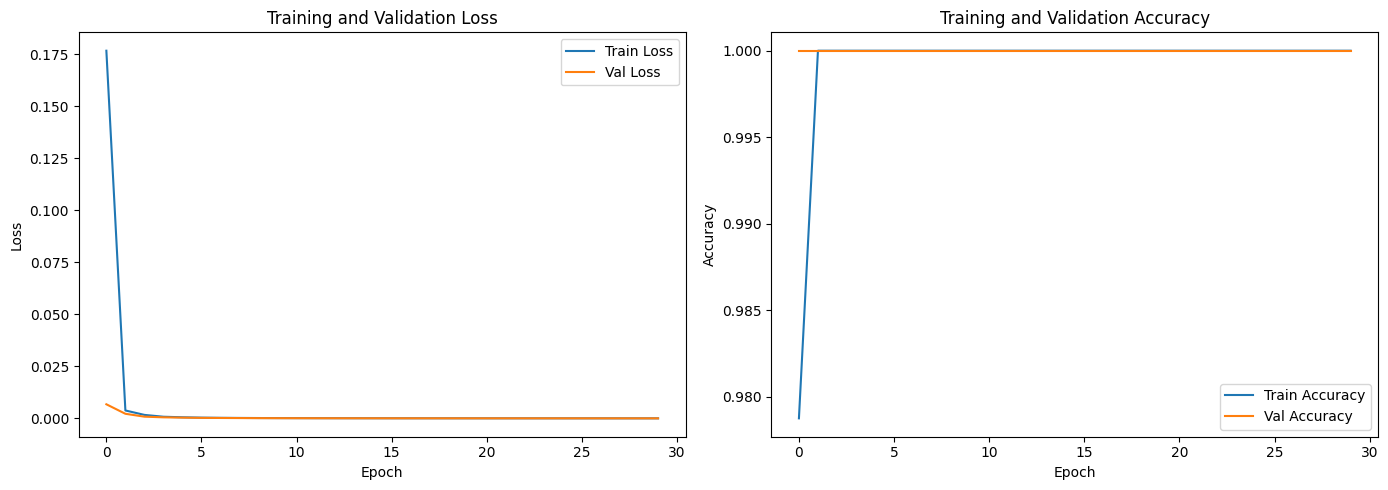

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()